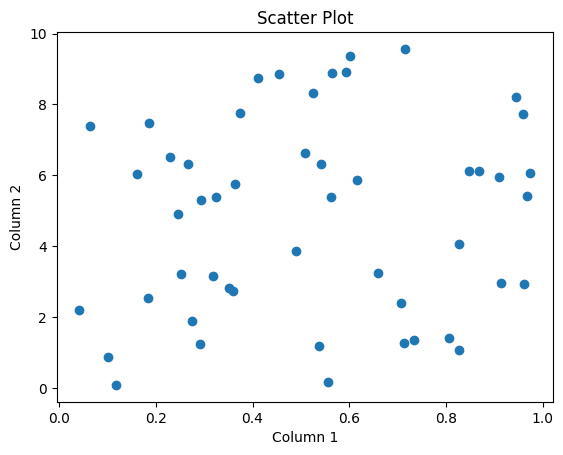

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.DataFrame({
    "column1": np.random.rand(50),
    "column2": np.random.rand(50) * 10,
})

plt.scatter(data["column1"], data["column2"])
plt.xlabel("Column 1")
plt.ylabel("Column 2")
plt.title("Scatter Plot")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import re
from ipaddress import ip_address
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

data = pd.read_csv("./data/demo_dataset.csv")

invalid_ips = ['INVALID_IP', 'MISSING_IP']
invalid_ports = ['STRING_PORT', 'UNUSED_PORT']
invalid_bytes = ['NON_NUMERIC', 'NEGATIVE']
invalid_threat = ['?']

data.replace(invalid_ips + invalid_ports + invalid_bytes + invalid_threat, np.nan, inplace=True)

data['destination_port'] = pd.to_numeric(data['destination_port'], errors='coerce')
data['bytes_transferred'] = pd.to_numeric(data['bytes_transferred'], errors='coerce')
data['threat_level'] = pd.to_numeric(data['threat_level'], errors='coerce')

def is_valid_ip(ip):
    pattern = re.compile(r'^((25[0-5]|2[0-4][0-9]|[01]?\d?\d)\.){3}(25[0-5]|2[0-4]\d|[01]?\d?\d)$')
    if pd.isna(ip) or not pattern.match(str(ip)):
        return np.nan
    return ip

data['source_ip'] = data['source_ip'].apply(is_valid_ip)

numeric_cols = ['destination_port', 'bytes_transferred', 'threat_level']
categorical_cols = ['protocol']

num_imputer = SimpleImputer(strategy='median')
data[numeric_cols] = num_imputer.fit_transform(data[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])

knn_imputer = KNNImputer(n_neighbors=5)
data[numeric_cols] = knn_imputer.fit_transform(data[numeric_cols])
valid_protocols = ['TCP', 'TLS', 'SSH', 'POP3', 'DNS', 'HTTPS', 'SMTP', 'FTP', 'UDP', 'HTTP']
data.loc[~data['protocol'].isin(valid_protocols), 'protocol'] = data['protocol'].mode()[0]

data['source_ip'] = data['source_ip'].fillna('0.0.0.0')
data['destination_port'] = data['destination_port'].clip(lower=0, upper=65535)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(data[['protocol']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['protocol']))
data = pd.concat([data.drop('protocol', axis=1), encoded_df], axis=1)

data["bytes_transferred"] = np.log1p(data["bytes_transferred"])

# Separate features (X) and target (y)
X = data.drop("threat_level", axis=1)
y = data["threat_level"]

# Initial split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

# Second split: from the 80% training portion, allocate 60% for final training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1337)



            log_id source_ip  destination_port protocol  bytes_transferred  \
count   100.000000       100        100.000000      100          100.00000   
unique         NaN        76               NaN        9                NaN   
top            NaN   0.0.0.0               NaN     HTTP                NaN   
freq           NaN        15               NaN       27                NaN   
mean     50.500000       NaN        776.860000      NaN         4138.64000   
std      29.011492       NaN       6542.582099      NaN         2526.40978   
min       1.000000       NaN         22.000000      NaN          498.00000   
25%      25.750000       NaN         53.000000      NaN         1693.25000   
50%      50.500000       NaN         80.000000      NaN         4096.00000   
75%      75.250000       NaN        110.000000      NaN         5971.75000   
max     100.000000       NaN      65535.000000      NaN         9765.00000   

        threat_level  
count     100.000000  
unique           